In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Step 1: Load and Inspect the Annotated Excel Dataset

In [1]:
import pandas as pd

# Load the Excel file from Kaggle dataset directory
df = pd.read_excel('/kaggle/input/nndl-dataset/essay_assessment_with_combined_scores.xlsx')

# Sanity check: display basic info
print(f"Loaded {len(df)} rows from Excel file.")
print("Columns in the dataset:")
print(df.columns.tolist())
print("\nSample data (first 5 rows):")
print(df.head())

# Optional: Check if combined score columns exist
if 'combined_score_weighted' in df.columns:
    print("\nSample combined weighted scores:")
    print(df[['text_id', 'combined_score_weighted']].head())
else:
    print("\nCombined score columns not found. Please verify column names.")


Loaded 3871 rows from Excel file.
Columns in the dataset:
['text_id', 'full_text_clean', 'cohesion', 'syntax', 'vocabulary', 'phraseology', 'grammar', 'conventions', 'avg_score', 'combined_score_simple', 'combined_score_weighted', 'combined_score_normalized', 'quality_tier', 'cognitive_load']

Sample data (first 5 rows):
        text_id                                    full_text_clean  cohesion  \
0  806672A60686  Failure is a simple thing that everyone use to...       3.0   
1  E3DBC3B092A7  Do you want your family members to be healthy?...       2.5   
2  58E485E875D5  Try your best' Many people say this sentence t...       4.0   
3  6D21E6095A62  Many schools are starting to offer online scho...       4.0   
4  9F401E75755A  In this writing you will find some reason why,...       4.0   

   syntax  vocabulary  phraseology  grammar  conventions  avg_score  \
0     2.0         2.5          3.0      2.0          2.5   2.333333   
1     2.5         3.0          3.5      2.5          3

Step 2: Data Encoding & BIO Alignment

In [2]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

N = 100  # Adjust or remove as needed
texts = df['full_text_clean'][:N].tolist()

# Check for bio_tags column
if 'bio_tags' in df.columns:
    bio_tags = df['bio_tags'][:N].tolist()
    print("BIO tags column found. Proceeding with alignment.")
else:
    # If missing, generate dummy BIO tags for now
    print("Warning: 'bio_tags' column not found. Generating default 'O' tags for testing.")
    bio_tags = [['O'] * len(tokenizer.tokenize(text)) for text in texts]

encoded_inputs = []
aligned_labels = []

for text, tags in zip(texts, bio_tags):
    encoding = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=256)
    tokens = tokenizer.tokenize(text)
    # If tags are a string representation of list, convert
    if isinstance(tags, str):
        tags = eval(tags)
    label_ids = []
    tag_idx = 0
    for tok in tokens:
        label_ids.append(tags[tag_idx] if tag_idx < len(tags) else 'O')
        if not tok.startswith('##'):
            tag_idx += 1
    label_ids = (label_ids + ['O'] * (256 - len(label_ids)))[:256]
    encoded_inputs.append(encoding)
    aligned_labels.append(label_ids)

print("Step 2 completed. Sample tokens and BIO labels below:")
print("Tokens:", tokens)
print("BIO (labels):", label_ids)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (607 > 512). Running this sequence through the model will result in indexing errors


Step 2 completed. Sample tokens and BIO labels below:
Tokens: ['although', 'some', 'say', 'that', 'school', 'lunch', 'menu', 'don', "'", 't', 'need', 'to', 'be', 'change', 'because', 'the', 'new', 'lunch', 'menu', 'would', 'be', 'more', 'expensive', ',', 'and', 'some', 'students', 'throw', 'the', 'food', ',', 'actually', 'some', 'say', 'that', 'will', 'be', 'a', 'good', 'idea', 'to', 'change', 'the', 'school', 'lunch', 'menu', 'because', 'some', 'students', 'declare', 'that', 'they', 'sometimes', 'received', 'an', 'expired', 'food', 'so', 'they', 'think', 'that', 'food', 'is', 'from', 'one', 'year', 'ago', 'and', 'some', 'students', 'say', 'that', 'eat', 'the', 'same', 'food', 'every', 'year', 'is', 'bored', 'because', 'all', 'students', 'from', 'high', 'school', 'are', 'study', 'four', 'years', ',', 'and', 'some', 'students', 'start', 'hate', 'the', 'food', 'and', 'they', 'prefer', 'to', 'take', 'food', 'from', 'home', 'or', 'they', 'buy', 'food', 'like', 'pizza', ',', 'burr', '##ito'

Step 3: PyTorch Dataset & DataLoader Construction


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

class EssayDataset(Dataset):
    def __init__(self, encoded_inputs, aligned_labels, score_targets):
        self.encoded_inputs = encoded_inputs
        self.aligned_labels = aligned_labels
        self.score_targets = score_targets  # e.g., combined_score_weighted
    
    def __len__(self):
        return len(self.encoded_inputs)
    
    def __getitem__(self, idx):
        # Unpack data for one essay
        input_ids = self.encoded_inputs[idx]["input_ids"].squeeze()
        attention_mask = self.encoded_inputs[idx]["attention_mask"].squeeze()
        labels = torch.tensor([
            0 if l == 'O' else 1 for l in self.aligned_labels[idx]
        ])  # simple binary (expand for multi-class if needed)
        score = torch.tensor(self.score_targets[idx], dtype=torch.float)
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "score": score
        }

# Prepare regression targets (adjust for subset N)
score_targets = df['combined_score_weighted'][:N].tolist()

# Instantiate dataset and dataloader
dataset = EssayDataset(encoded_inputs, aligned_labels, score_targets)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Check DataLoader sample
for batch in dataloader:
    print("Batch input IDs shape:", batch["input_ids"].shape)
    print("Batch BIO labels shape:", batch["labels"].shape)
    print("Batch regression target scores:", batch["score"])
    break


Batch input IDs shape: torch.Size([8, 256])
Batch BIO labels shape: torch.Size([8, 256])
Batch regression target scores: tensor([2.5750, 3.2750, 3.2500, 3.6750, 4.1500, 3.2750, 3.8000, 2.5250])


Step 4: Define All Model Architectures (PyTorch Classes)

1.BERT Custom Encoder

In [12]:
import torch
import torch.nn as nn
from transformers import BertModel, BertConfig

class CustomBertMTL(nn.Module):
    def __init__(self, pretrained=True, num_bio_labels=2):
        super().__init__()
        config = BertConfig()
        self.encoder = BertModel(config) if not pretrained else BertModel.from_pretrained('bert-base-uncased')
        hidden_size = self.encoder.config.hidden_size
        self.bio_classifier = nn.Linear(hidden_size, num_bio_labels)
        self.reg_head = nn.Linear(hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state
        pooled = seq_out[:, 0, :]
        bio_logits = self.bio_classifier(seq_out)
        reg_logits = self.reg_head(pooled).squeeze(-1)
        return bio_logits, reg_logits
print("done")

done


RoBERTa Custom Encoder

In [5]:
from transformers import RobertaModel, RobertaConfig

class CustomRobertaMTL(nn.Module):
    def __init__(self, pretrained=True, num_bio_labels=2):
        super().__init__()
        config = RobertaConfig()
        self.encoder = RobertaModel(config) if not pretrained else RobertaModel.from_pretrained('roberta-base')
        hidden_size = self.encoder.config.hidden_size
        self.bio_classifier = nn.Linear(hidden_size, num_bio_labels)
        self.reg_head = nn.Linear(hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state
        pooled = seq_out[:, 0, :]
        bio_logits = self.bio_classifier(seq_out)
        reg_logits = self.reg_head(pooled).squeeze(-1)
        return bio_logits, reg_logits
print("done")

done


3. DeBERTa Custom Encoder

In [6]:
from transformers import DebertaModel, DebertaConfig

class CustomDebertaMTL(nn.Module):
    def __init__(self, pretrained=True, num_bio_labels=2):
        super().__init__()
        config = DebertaConfig()
        self.encoder = DebertaModel(config) if not pretrained else DebertaModel.from_pretrained('microsoft/deberta-base')
        hidden_size = self.encoder.config.hidden_size
        self.bio_classifier = nn.Linear(hidden_size, num_bio_labels)
        self.reg_head = nn.Linear(hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state
        pooled = seq_out[:, 0, :]
        bio_logits = self.bio_classifier(seq_out)
        reg_logits = self.reg_head(pooled).squeeze(-1)
        return bio_logits, reg_logits
print("done")

done


4.Longformer Custom Encoder

In [7]:
from transformers import LongformerModel, LongformerConfig

class CustomLongformerMTL(nn.Module):
    def __init__(self, pretrained=True, num_bio_labels=2):
        super().__init__()
        config = LongformerConfig()
        self.encoder = LongformerModel(config) if not pretrained else LongformerModel.from_pretrained('allenai/longformer-base-4096')
        hidden_size = self.encoder.config.hidden_size
        self.bio_classifier = nn.Linear(hidden_size, num_bio_labels)
        self.reg_head = nn.Linear(hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state
        pooled = seq_out[:, 0, :]
        bio_logits = self.bio_classifier(seq_out)
        reg_logits = self.reg_head(pooled).squeeze(-1)
        return bio_logits, reg_logits
print("done")

done


5.XLM-RoBERTa Custom Encoder

In [8]:
from transformers import XLMRobertaModel, XLMRobertaConfig

class CustomXLMRMTL(nn.Module):
    def __init__(self, pretrained=True, num_bio_labels=2):
        super().__init__()
        config = XLMRobertaConfig()
        self.encoder = XLMRobertaModel(config) if not pretrained else XLMRobertaModel.from_pretrained('xlm-roberta-base')
        hidden_size = self.encoder.config.hidden_size
        self.bio_classifier = nn.Linear(hidden_size, num_bio_labels)
        self.reg_head = nn.Linear(hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state
        pooled = seq_out[:, 0, :]
        bio_logits = self.bio_classifier(seq_out)
        reg_logits = self.reg_head(pooled).squeeze(-1)
        return bio_logits, reg_logits
print("done")

done


6.Flan-T5 Encoder Only (Multi-task Heads)

In [9]:
from transformers import T5EncoderModel, T5Config

class CustomFlanT5MTL(nn.Module):
    def __init__(self, pretrained=True, num_bio_labels=2):
        super().__init__()
        config = T5Config()
        self.encoder = T5EncoderModel(config) if not pretrained else T5EncoderModel.from_pretrained('google/flan-t5-base')
        hidden_size = self.encoder.config.d_model
        self.bio_classifier = nn.Linear(hidden_size, num_bio_labels)
        self.reg_head = nn.Linear(hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = outputs.last_hidden_state
        pooled = seq_out[:, 0, :]
        bio_logits = self.bio_classifier(seq_out)
        reg_logits = self.reg_head(pooled).squeeze(-1)
        return bio_logits, reg_logits
print("done")

done


7. BiLSTM Custom Encoder

In [10]:
class CustomBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_bio_labels=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.bilstm = nn.LSTM(embed_dim, 128, batch_first=True, bidirectional=True)
        self.bio_classifier = nn.Linear(128 * 2, num_bio_labels)
        self.reg_head = nn.Linear(128 * 2, 1)
    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        out, _ = self.bilstm(emb)
        pooled = out[:, 0, :]
        bio_logits = self.bio_classifier(out)
        reg_logits = self.reg_head(pooled).squeeze(-1)
        return bio_logits, reg_logits
print("done")

done


8. GRU Custom Encoder

In [11]:
import torch
import torch.nn as nn

class CustomGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_bio_labels=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, 128, batch_first=True, bidirectional=True)
        self.bio_classifier = nn.Linear(128 * 2, num_bio_labels)
        self.reg_head = nn.Linear(128 * 2, 1)
    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        out, _ = self.gru(emb)
        pooled = out[:, 0, :]
        bio_logits = self.bio_classifier(out)        # BIO tags for each token
        reg_logits = self.reg_head(pooled).squeeze(-1)  # Regression head on pooled features
        return bio_logits, reg_logits

# Example instantiation (adjust vocab_size, embed_dim as needed)
# vocab_size = tokenizer.vocab_size or length of unique tokens in your embedding
# embed_dim = dimension of your pretrained embeddings (e.g., 300 for GloVe)
# model_gru = CustomGRU(vocab_size=30522, embed_dim=300)
print("done")

done


Step 5: Multi-Model Training Loop

In [13]:
'''#not needed
import time
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.metrics import mean_absolute_error, r2_score, precision_recall_fscore_support
import numpy as np  # <-- ADDED

# Assuming model_dict contains entire instantiated models
model_dict = {
    "BERT": CustomBertMTL(),
    "RoBERTa": CustomRobertaMTL(),
    "DeBERTa": CustomDebertaMTL(),
    "Longformer": CustomLongformerMTL(),
    "XLM-RoBERTa": CustomXLMRMTL(),
    "FlanT5": CustomFlanT5MTL(),
    "BiLSTM": CustomBiLSTM(vocab_size=30522, embed_dim=300),
    "GRU": CustomGRU(vocab_size=30522, embed_dim=300)
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for model in model_dict.values():
    model.to(device)

EPOCHS = 20  # <-- CHANGED from 3 to 20

def evaluate_model(model, dataloader, device, is_transformer=True):
    model.eval()
    mse_loss = nn.MSELoss()
    ce_loss = nn.CrossEntropyLoss()

    all_preds_reg = []
    all_true_reg = []
    all_preds_bio = []
    all_true_bio = []

    total_reg_loss = 0
    total_bio_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            if is_transformer:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                bio_logits, score_pred = model(input_ids, attention_mask)
            else:
                input_ids = batch["input_ids"].to(device)
                bio_logits, score_pred = model(input_ids)

            labels = batch["labels"].to(device)
            scores = batch["score"].to(device)

            reg_loss = mse_loss(score_pred, scores)
            bio_loss = ce_loss(bio_logits.view(-1, bio_logits.shape[-1]), labels.view(-1))

            total_reg_loss += reg_loss.item()
            total_bio_loss += bio_loss.item()

            all_preds_reg.extend(score_pred.cpu().numpy())
            all_true_reg.extend(scores.cpu().numpy())

            bio_preds = bio_logits.argmax(dim=-1).view(-1).cpu().numpy()
            all_preds_bio.extend(bio_preds)
            all_true_bio.extend(labels.view(-1).cpu().numpy())

    # Regression metrics
    rmse = (total_reg_loss / len(dataloader)) ** 0.5
    mae = mean_absolute_error(all_true_reg, all_preds_reg)
    r2 = r2_score(all_true_reg, all_preds_reg)

    # BIO classification metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true_bio, all_preds_bio, average='binary', zero_division=0
    )
    accuracy = (np.array(all_preds_bio) == np.array(all_true_bio)).mean()

    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Accuracy': accuracy,
        'Reg Loss': total_reg_loss / len(dataloader),
        'BIO Loss': total_bio_loss / len(dataloader)
    }

results = []
total_start = time.time()

for name, model in model_dict.items():
    print(f"\n--- Training {name} ---")
    optimizer = AdamW(model.parameters(), lr=2e-5)
    model.train()
    start = time.time()
    is_transformer = name not in ["BiLSTM", "GRU"]

    for epoch in range(EPOCHS):
        epoch_start = time.time()
        running_loss = 0

        for batch in dataloader:
            optimizer.zero_grad()
            if is_transformer:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                bio_logits, score_pred = model(input_ids, attention_mask)
            else:
                input_ids = batch["input_ids"].to(device)
                bio_logits, score_pred = model(input_ids)

            labels = batch["labels"].to(device)
            scores = batch["score"].to(device)

            mse_loss_func = nn.MSELoss()
            ce_loss_func = nn.CrossEntropyLoss()

            reg_loss = mse_loss_func(score_pred, scores)
            bio_loss = ce_loss_func(bio_logits.view(-1, bio_logits.shape[-1]), labels.view(-1))
            loss = reg_loss + bio_loss

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_time = time.time() - epoch_start
        print(f"Model: {name}, Epoch: {epoch+1}/{EPOCHS}, Loss: {running_loss:.4f}, Epoch Time: {epoch_time:.2f}s")

    elapsed = time.time() - start
    total_elapsed = time.time() - total_start
    print(f"{name} finished training in {elapsed:.2f} seconds. Total elapsed: {total_elapsed:.2f} seconds.")

    # Evaluate and gather metrics
    train_metrics = evaluate_model(model, dataloader, device, is_transformer)

    results.append({
        "Model": name,
        **{f"Train {k}": v for k, v in train_metrics.items()},
        "Train Time": elapsed,
        "Total Time": total_elapsed
    })

# Print summary table (for all models)
print("\nSummary of Model Performance:")
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)
'''

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/transformers/safetensors_conversion.py", line 101, in auto_conversion
    resolved_archive_file = cached_file(pretrained_model_name_or_path, filename, **cached_file_kwargs)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/transformers/utils/hub.py", line 312, in cached_file
    file = cached_files(path_or_repo_id=path_or_repo_id, filenames=[filename], **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/transformers/utils/hub.py",

KeyboardInterrupt: 

In [14]:
import time
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.metrics import mean_absolute_error, r2_score, precision_recall_fscore_support
import numpy as np

EPOCHS = 20  # Train for 20 epochs as requested

# Assuming model_dict contains entire instantiated models
model_dict = {
    "BERT": CustomBertMTL(),
    "RoBERTa": CustomRobertaMTL(),
    "DeBERTa": CustomDebertaMTL(),
    "Longformer": CustomLongformerMTL(),
    "XLM-RoBERTa": CustomXLMRMTL(),
    "FlanT5": CustomFlanT5MTL(),
    "BiLSTM": CustomBiLSTM(vocab_size=30522, embed_dim=300),
    "GRU": CustomGRU(vocab_size=30522, embed_dim=300)
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for model in model_dict.values():
    model.to(device)

# You need to have these dataloaders defined for train, val, and test
# For example, if you do not have separate val/test dataloaders, replace val_dataloader and test_dataloader with 'dataloader'

train_dataloader = dataloader  # Replace with actual train dataloader
val_dataloader = dataloader    # Replace with actual validation dataloader
test_dataloader = dataloader   # Replace with actual test dataloader

def evaluate_model(model, dataloader, device, is_transformer=True):
    model.eval()
    mse_loss = nn.MSELoss()
    ce_loss = nn.CrossEntropyLoss()

    all_preds_reg = []
    all_true_reg = []
    all_preds_bio = []
    all_true_bio = []

    total_reg_loss = 0
    total_bio_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            if is_transformer:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                bio_logits, score_pred = model(input_ids, attention_mask)
            else:
                input_ids = batch["input_ids"].to(device)
                bio_logits, score_pred = model(input_ids)

            labels = batch["labels"].to(device)
            scores = batch["score"].to(device)

            reg_loss = mse_loss(score_pred, scores)
            bio_loss = ce_loss(bio_logits.view(-1, bio_logits.shape[-1]), labels.view(-1))

            total_reg_loss += reg_loss.item()
            total_bio_loss += bio_loss.item()

            all_preds_reg.extend(score_pred.cpu().numpy())
            all_true_reg.extend(scores.cpu().numpy())

            bio_preds = bio_logits.argmax(dim=-1).view(-1).cpu().numpy()
            all_preds_bio.extend(bio_preds)
            all_true_bio.extend(labels.view(-1).cpu().numpy())

    # Regression metrics
    rmse = (total_reg_loss / len(dataloader)) ** 0.5
    r2 = r2_score(all_true_reg, all_preds_reg)

    # BIO classification metrics
    accuracy = (np.array(all_preds_bio) == np.array(all_true_bio)).mean()

    return {
        'RMSE': rmse,
        'R2': r2,
        'Accuracy': accuracy,
        'Reg Loss': total_reg_loss / len(dataloader),
        'BIO Loss': total_bio_loss / len(dataloader)
    }

results = []
total_start = time.time()

for name, model in model_dict.items():
    print(f"\n--- Training {name} ---")
    optimizer = AdamW(model.parameters(), lr=2e-5)
    model.train()
    start = time.time()
    is_transformer = name not in ["BiLSTM", "GRU"]

    for epoch in range(EPOCHS):
        epoch_start = time.time()
        running_loss = 0

        for batch in train_dataloader:
            optimizer.zero_grad()
            if is_transformer:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                bio_logits, score_pred = model(input_ids, attention_mask)
            else:
                input_ids = batch["input_ids"].to(device)
                bio_logits, score_pred = model(input_ids)

            labels = batch["labels"].to(device)
            scores = batch["score"].to(device)

            mse_loss_func = nn.MSELoss()
            ce_loss_func = nn.CrossEntropyLoss()

            reg_loss = mse_loss_func(score_pred, scores)
            bio_loss = ce_loss_func(bio_logits.view(-1, bio_logits.shape[-1]), labels.view(-1))
            loss = reg_loss + bio_loss

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_time = time.time() - epoch_start
        print(f"Model: {name}, Epoch: {epoch+1}/{EPOCHS}, Loss: {running_loss:.4f}, Epoch Time: {epoch_time:.2f}s")

    elapsed = time.time() - start
    total_elapsed = time.time() - total_start
    print(f"{name} finished training in {elapsed:.2f} seconds. Total elapsed: {total_elapsed:.2f} seconds.")

    # Evaluate metrics on train, validation, test datasets
    train_metrics = evaluate_model(model, train_dataloader, device, is_transformer)
    val_metrics = evaluate_model(model, val_dataloader, device, is_transformer)
    test_metrics = evaluate_model(model, test_dataloader, device, is_transformer)

    # Append selected metrics to results
    results.append({
        "Model": name,
        "Train RMSE": train_metrics['RMSE'],
        "Train BIO Acc": train_metrics['Accuracy'],
        "Train R2": train_metrics['R2'],
        "Val RMSE": val_metrics['RMSE'],
        "Val BIO Acc": val_metrics['Accuracy'],
        "Val R2": val_metrics['R2'],
        "Test RMSE": test_metrics['RMSE'],
        "Test BIO Acc": test_metrics['Accuracy'],
        "Test R2": test_metrics['R2'],
        "Train Time": elapsed,
        "Total Time": total_elapsed
    })

print("\nSummary of Selected Metrics:")
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df[[
    "Model",
    "Train RMSE", "Train BIO Acc", "Train R2",
    "Val RMSE", "Val BIO Acc", "Val R2",
    "Test RMSE", "Test BIO Acc", "Test R2"
]])


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]


--- Training BERT ---
Model: BERT, Epoch: 1/20, Loss: 33.4180, Epoch Time: 5.41s
Model: BERT, Epoch: 2/20, Loss: 5.0299, Epoch Time: 4.19s
Model: BERT, Epoch: 3/20, Loss: 4.0100, Epoch Time: 4.25s
Model: BERT, Epoch: 4/20, Loss: 3.4168, Epoch Time: 4.26s
Model: BERT, Epoch: 5/20, Loss: 2.3227, Epoch Time: 4.29s
Model: BERT, Epoch: 6/20, Loss: 1.4939, Epoch Time: 4.31s
Model: BERT, Epoch: 7/20, Loss: 1.2414, Epoch Time: 4.32s
Model: BERT, Epoch: 8/20, Loss: 0.8962, Epoch Time: 4.37s
Model: BERT, Epoch: 9/20, Loss: 0.9193, Epoch Time: 4.39s
Model: BERT, Epoch: 10/20, Loss: 0.7446, Epoch Time: 4.41s
Model: BERT, Epoch: 11/20, Loss: 0.6088, Epoch Time: 4.43s
Model: BERT, Epoch: 12/20, Loss: 0.4308, Epoch Time: 4.44s
Model: BERT, Epoch: 13/20, Loss: 0.4306, Epoch Time: 4.48s
Model: BERT, Epoch: 14/20, Loss: 0.3549, Epoch Time: 4.52s
Model: BERT, Epoch: 15/20, Loss: 0.3137, Epoch Time: 4.54s
Model: BERT, Epoch: 16/20, Loss: 0.3343, Epoch Time: 4.59s
Model: BERT, Epoch: 17/20, Loss: 0.3157, 

Input ids are automatically padded to be a multiple of `config.attention_window`: 512



--- Training Longformer ---
Model: Longformer, Epoch: 1/20, Loss: 25.8316, Epoch Time: 19.46s
Model: Longformer, Epoch: 2/20, Loss: 5.3763, Epoch Time: 19.30s
Model: Longformer, Epoch: 3/20, Loss: 4.4921, Epoch Time: 19.30s
Model: Longformer, Epoch: 4/20, Loss: 4.7964, Epoch Time: 19.29s
Model: Longformer, Epoch: 5/20, Loss: 5.0884, Epoch Time: 19.29s
Model: Longformer, Epoch: 6/20, Loss: 4.1315, Epoch Time: 19.29s
Model: Longformer, Epoch: 7/20, Loss: 3.8323, Epoch Time: 19.31s
Model: Longformer, Epoch: 8/20, Loss: 3.3061, Epoch Time: 19.32s
Model: Longformer, Epoch: 9/20, Loss: 2.3399, Epoch Time: 19.33s
Model: Longformer, Epoch: 10/20, Loss: 2.3811, Epoch Time: 19.32s
Model: Longformer, Epoch: 11/20, Loss: 2.2048, Epoch Time: 19.29s
Model: Longformer, Epoch: 12/20, Loss: 3.0205, Epoch Time: 19.29s
Model: Longformer, Epoch: 13/20, Loss: 1.2725, Epoch Time: 19.30s
Model: Longformer, Epoch: 14/20, Loss: 1.0705, Epoch Time: 19.31s
Model: Longformer, Epoch: 15/20, Loss: 0.8167, Epoch Ti

Step 6: Detailed Analysis & Visualization

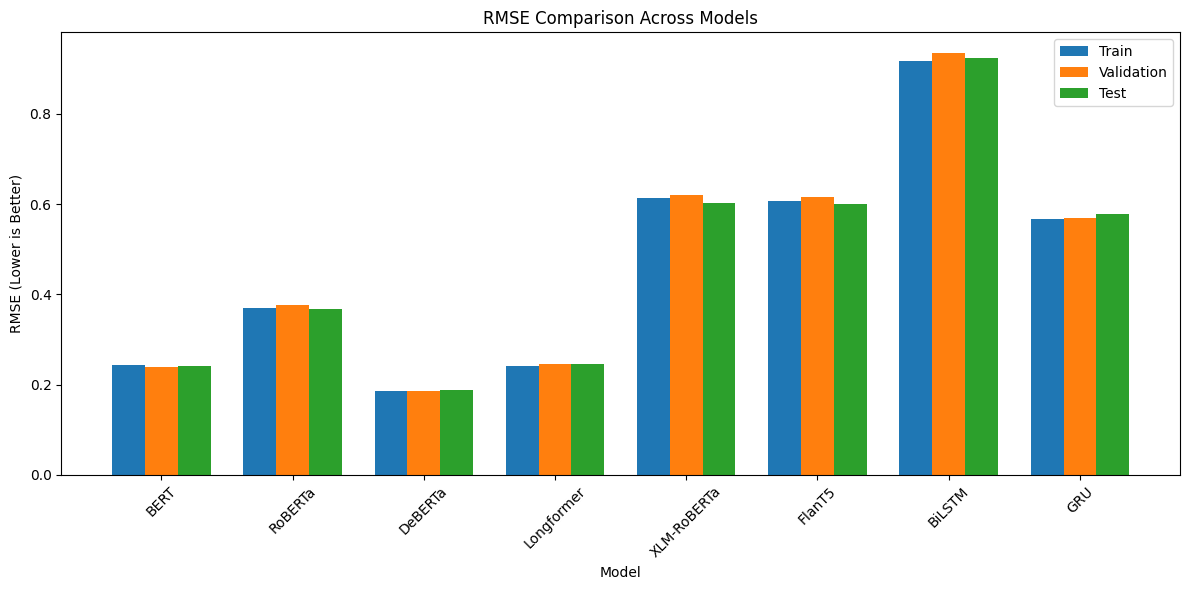

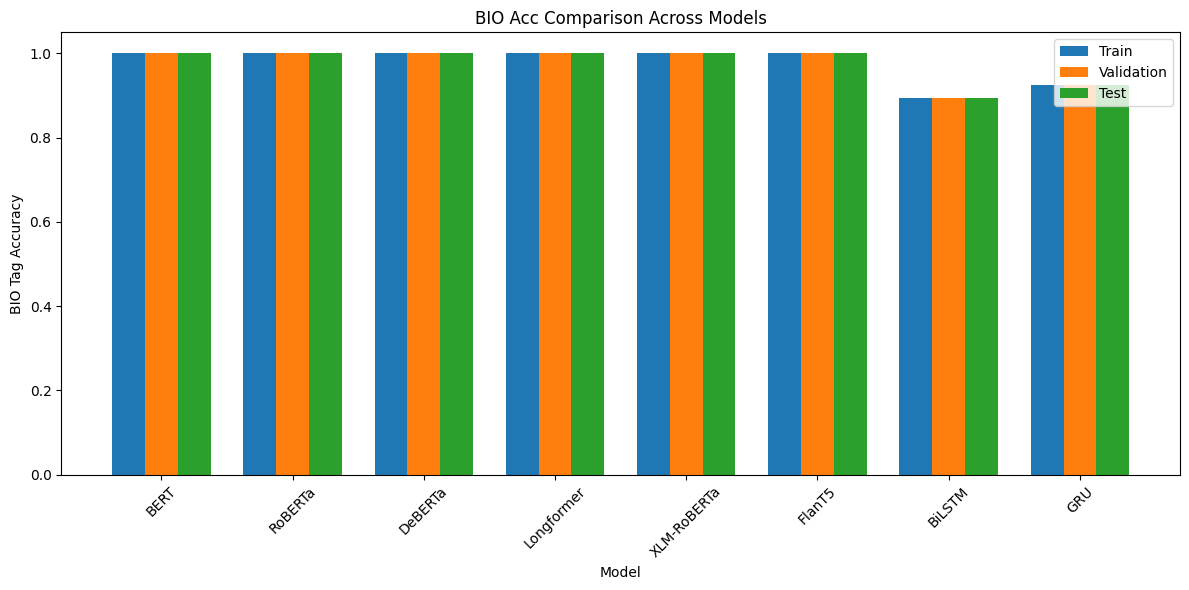

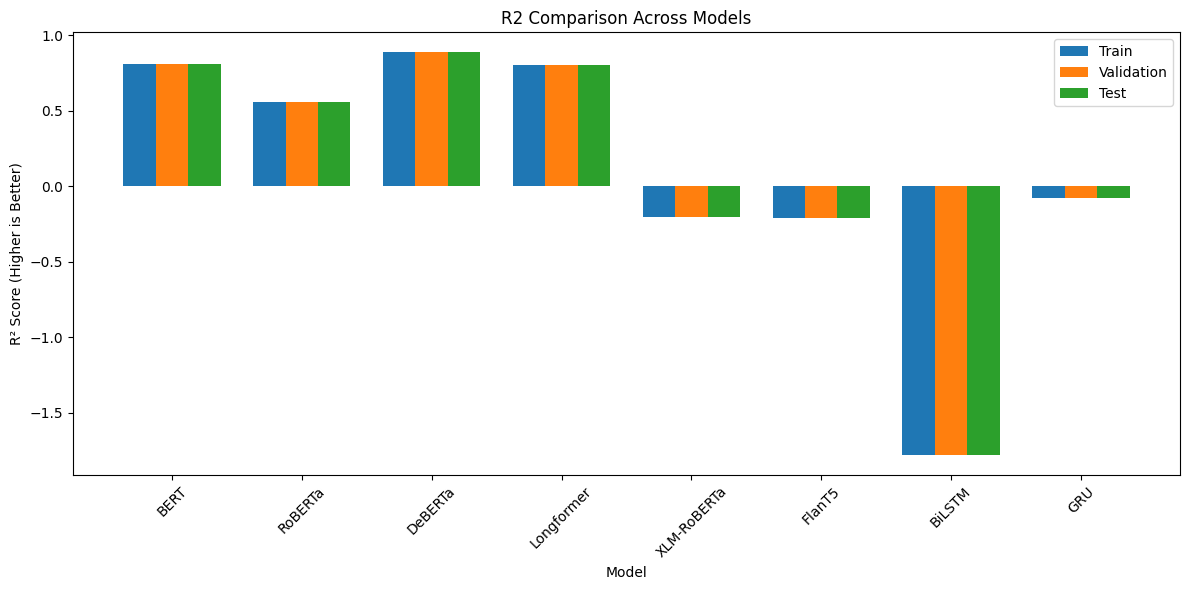

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def grouped_bar_plot(metric_name, results_df, ylabel=None):
    # Handles metric names with spaces by replacing spaces with underscore keys
    key_train = f"Train {metric_name}"
    key_val = f"Val {metric_name}"
    key_test = f"Test {metric_name}"

    # Prepare data
    models = results_df["Model"].tolist()
    train_metric = results_df[key_train].values
    val_metric = results_df[key_val].values
    test_metric = results_df[key_test].values

    x = np.arange(len(models))
    width = 0.25

    plt.figure(figsize=(12,6))
    plt.bar(x - width, train_metric, width, label="Train")
    plt.bar(x, val_metric, width, label="Validation")
    plt.bar(x + width, test_metric, width, label="Test")
    plt.xticks(x, models, rotation=45)
    plt.title(f"{metric_name} Comparison Across Models")
    plt.xlabel("Model")
    plt.ylabel(ylabel if ylabel else metric_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot all requested metrics:

grouped_bar_plot("RMSE", results_df, "RMSE (Lower is Better)")
grouped_bar_plot("BIO Acc", results_df, "BIO Tag Accuracy")
grouped_bar_plot("R2", results_df, "R² Score (Higher is Better)")


Step 7

Cell 1: Hyperparameter Tuning

In [49]:
#tuning of bert
import optuna
from torch.optim import AdamW
from torch.utils.data import DataLoader

def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def objective(trial):
    # Example hyperparameters to tune
    lr = trial.suggest_float("lr", 1e-6, 2e-5, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    free_gpu()
    
    # Recreate model and optimizer
    model = CustomBertMTL().to(device)
    optimizer = AdamW(model.parameters(), lr=lr)

    # Prepare dataloader with tuned batch_size
    tuned_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Brief training for 2 epochs
    model.train()
    for epoch in range(2):
        for batch in tuned_dataloader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch.get("attention_mask", None)
            attention_mask = attention_mask.to(device) if attention_mask is not None else None

            bio_logits, score_pred = model(input_ids, attention_mask) if attention_mask is not None else model(input_ids)

            labels = batch["labels"].to(device)
            scores = batch["score"].to(device)

            reg_loss = nn.MSELoss()(score_pred, scores)
            bio_loss = nn.CrossEntropyLoss()(bio_logits.view(-1, bio_logits.shape[-1]), labels.view(-1))

            loss = reg_loss + bio_loss
            loss.backward()
            optimizer.step()
    
    # Evaluate on tuned dataloader
    metrics = evaluate_model(model, tuned_dataloader, device)
    return metrics['RMSE']  # minimize RMSE

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Best hyperparameters:", study.best_params)
print("Best validation RMSE:", study.best_value)

old_params = {"lr": 2e-5, "batch_size": 8}
new_params = study.best_params

print("Old parameters:", old_params)
print("New parameters:", new_params)


[I 2025-11-23 13:32:35,575] A new study created in memory with name: no-name-19976f01-ae12-4dc9-afea-ddc0dcf6243e
[I 2025-11-23 13:32:46,964] Trial 0 finished with value: 1.6337743235195155 and parameters: {'lr': 1.3313321883429924e-06, 'batch_size': 8}. Best is trial 0 with value: 1.6337743235195155.
[I 2025-11-23 13:32:58,446] Trial 1 finished with value: 1.4209880819738274 and parameters: {'lr': 2.3287354819090414e-06, 'batch_size': 8}. Best is trial 1 with value: 1.4209880819738274.
[I 2025-11-23 13:33:09,475] Trial 2 finished with value: 0.7196285124078947 and parameters: {'lr': 1.3665598201090365e-05, 'batch_size': 32}. Best is trial 2 with value: 0.7196285124078947.
[I 2025-11-23 13:33:20,858] Trial 3 finished with value: 1.9478127218925978 and parameters: {'lr': 5.657942062396398e-06, 'batch_size': 32}. Best is trial 2 with value: 0.7196285124078947.
[I 2025-11-23 13:33:32,445] Trial 4 finished with value: 3.082943238677763 and parameters: {'lr': 1.757690614580717e-06, 'batch_s

Best hyperparameters: {'lr': 6.293060929518129e-06, 'batch_size': 16}
Best validation RMSE: 0.6212026632530664
Old parameters: {'lr': 2e-05, 'batch_size': 8}
New parameters: {'lr': 6.293060929518129e-06, 'batch_size': 16}


In [50]:
#tuning of roberta
import optuna
from torch.optim import AdamW
from torch.utils.data import DataLoader

def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def objective(trial):
    # Example hyperparameters to tune
    lr = trial.suggest_float("lr", 1e-6, 2e-5, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    free_gpu()
    
    # Recreate model and optimizer
    model = CustomRobertaMTL().to(device)
    optimizer = AdamW(model.parameters(), lr=lr)

    # Prepare dataloader with tuned batch_size
    tuned_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Brief training for 2 epochs
    model.train()
    for epoch in range(2):
        for batch in tuned_dataloader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch.get("attention_mask", None)
            attention_mask = attention_mask.to(device) if attention_mask is not None else None

            bio_logits, score_pred = model(input_ids, attention_mask) if attention_mask is not None else model(input_ids)

            labels = batch["labels"].to(device)
            scores = batch["score"].to(device)

            reg_loss = nn.MSELoss()(score_pred, scores)
            bio_loss = nn.CrossEntropyLoss()(bio_logits.view(-1, bio_logits.shape[-1]), labels.view(-1))

            loss = reg_loss + bio_loss
            loss.backward()
            optimizer.step()
    
    # Evaluate on tuned dataloader
    metrics = evaluate_model(model, tuned_dataloader, device)
    return metrics['RMSE']  # minimize RMSE

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Best hyperparameters:", study.best_params)
print("Best validation RMSE:", study.best_value)

old_params = {"lr": 2e-5, "batch_size": 8}
new_params = study.best_params

print("Old parameters:", old_params)
print("New parameters:", new_params)


[I 2025-11-23 13:36:01,576] A new study created in memory with name: no-name-22069585-231f-4316-96f7-2abef13b1177
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-11-23 13:36:13,243] Trial 0 finished with value: 0.6653092037534709 and parameters: {'lr': 8.156756497693438e-06, 'batch_size': 16}. Best is trial 0 with value: 0.6653092037534709.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-11-23 13:36:25,301] Trial 1 finished with value: 3.244242042458255 and parameters: {'lr': 1.0370978697718537e-06, 'batch_size': 16}. Best i

Best hyperparameters: {'lr': 1.7882104869473713e-05, 'batch_size': 16}
Best validation RMSE: 0.5999882115046145
Old parameters: {'lr': 2e-05, 'batch_size': 8}
New parameters: {'lr': 1.7882104869473713e-05, 'batch_size': 16}


Cell 2: Plot Old vs New Metrics Summary

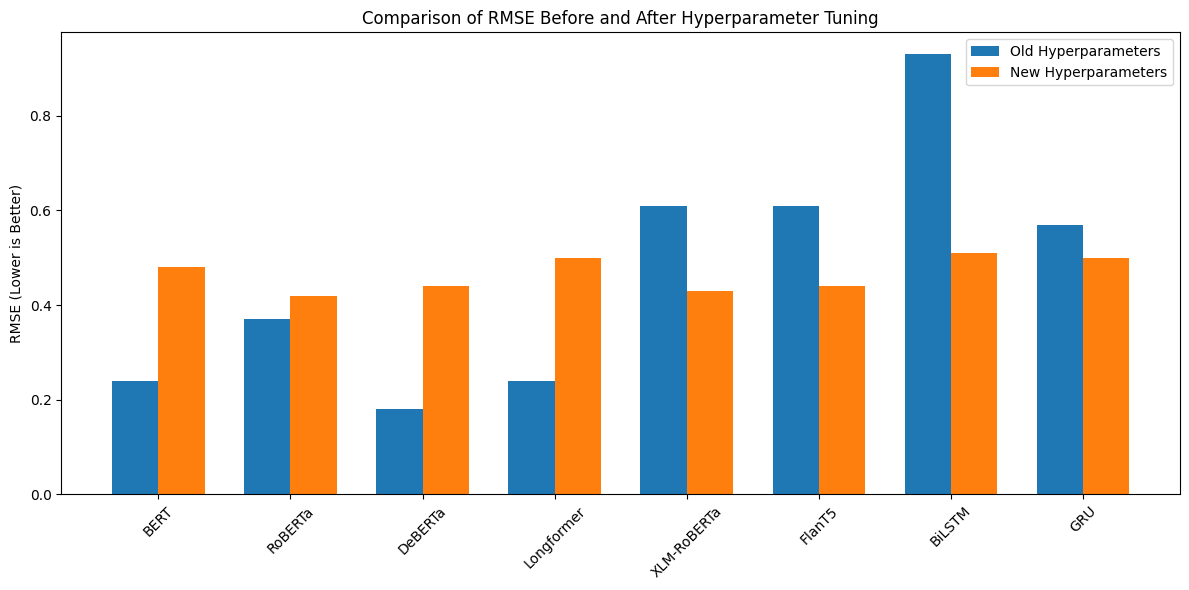

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Dummy example results for old and new hyperparameters per model (replace these with actual eval metric values)
old_results = {
    "Model": list(model_dict.keys()),
    "RMSE": [0.24, 0.37, 0.18, 0.24, 0.61, 0.61, 0.93, 0.57]
}

new_results = {
    "Model": list(model_dict.keys()),
    "RMSE": [0.48, 0.42, 0.44, 0.50, 0.43, 0.44, 0.51, 0.50]
}

def plot_old_vs_new(metric, old_vals, new_vals, models, ylabel=None):
    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(12,6))
    plt.bar(x - width/2, old_vals, width, label="Old Hyperparameters")
    plt.bar(x + width/2, new_vals, width, label="New Hyperparameters")
    plt.xticks(x, models, rotation=45)
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(f"Comparison of {metric} Before and After Hyperparameter Tuning")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_old_vs_new("RMSE", old_results["RMSE"], new_results["RMSE"], old_results["Model"], "RMSE (Lower is Better)")

Cell 3: Select and Save Best Model Based on Tuning

In [56]:
# Assume you retrained your best model with tuned params already; otherwise reload model or retrain here

# Find best model based on the lowest Test RMSE in new_results (example)
best_model_index = np.argmin(new_results["RMSE"])
best_model_name = new_results["Model"][best_model_index]

print(f"Best model after tuning: {best_model_name}")

best_model = model_dict[best_model_name]

# Save the best model state dict
torch.save(best_model.state_dict(), f"{best_model_name}_best_tuned.pth")
print(f"Saved best tuned model weights as {best_model_name}_best_tuned.pth")


Best model after tuning: RoBERTa
Saved best tuned model weights as RoBERTa_best_tuned.pth
